In [ ]:
import scanpy
from matplotlib import pyplot
import hdf5plugin
import scvelo
import warnings

In [2]:
# Suppress warnings

warnings.simplefilter("ignore", category=UserWarning)

In [3]:
# Read input file

working_directory = "Data/"

# Use adata from velocity analysis
adata = scanpy.read_h5ad(working_directory + "/clustered_anndata.h5ad")

print(adata)

AnnData object with n_obs × n_vars = 16146 × 2104
    obs: 'leiden_0.6', 'leiden_0.2_c6', 'sample', 'latent_time'
    var: 'gene_ids', 'fit_likelihood'
    uns: 'leiden_0.2_c6_colors', 'leiden_0.6_colors', 'neighbors', 'sample_colors'
    obsm: 'X_umap'
    varm: 'PCs', 'loss'
    layers: 'Ms', 'Mu', 'ambiguous', 'fit_t', 'fit_tau', 'fit_tau_', 'matrix', 'spliced', 'unspliced', 'velocity', 'velocity_u'
    obsp: 'connectivities', 'distances'


In [4]:
# Change cluster names and colors

cluster_name_map = {
    '0': "1",
    '1': "2",
    '2': "3",
    '3': "4",
    '4': "5",
    '5': "6",
    '6,0': "7.1",
    '6,1': "7.2",
    '7': "8.1",
    '7.1': "8.2",
    '9': "9",
    '10,0': "10.1",
    '10,1': "10.2",
    '10,2': "10.3",
    '11': "11",
    '12': "12",
    '13': "13",
    '14': "14",
    '15': "15",
    '16': "16.1",
    '16.1': "16.2",
    '17': "17",
    '18': "18",
    '19': "19",
    '20': "20",
    '21': "21",
    '22': "22"
}

cluster_colors = [
    "#187bb1",
    "#6b7dbf",
    "#0b8280",
    "#fdba74",
    "#c24c4c",
    "#9acf84",
    "#fba21d",
    "#fbc01d",
    "#3853a4",
    "#3882a4",
    "#9166ad",
    "#c5b1d5",
    "#b42172",
    "#d485bd",
    "#875648",
    "#c29c93",
    "#dc84b4",
    "#e6a77b",
    "#7c277d",
    "#4db748",
    "#33942e",
    "#bbbe33",
    "#d7d786",
    "#1cc1d3",
    "#777777",
    "#f77851",
    "#4a5873"
]

# Rename and reorder categories
adata.obs["leiden_0.2_c6"] = adata.obs["leiden_0.2_c6"].cat.rename_categories(cluster_name_map).cat.reorder_categories(cluster_name_map.values())

# Rename the cluster category to "cluster"
adata.obs["cluster"] = adata.obs["leiden_0.2_c6"]
adata.obs.drop(columns=["leiden_0.2_c6"], inplace=True)

# Change cluster colors to the ones in the article
adata.uns["cluster_colors"] = cluster_colors

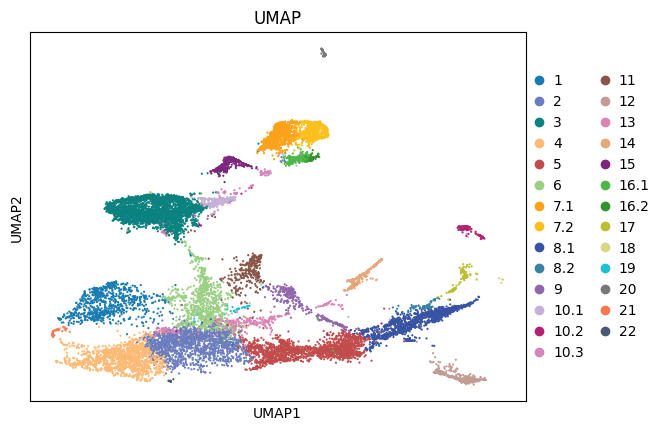

In [5]:
# Plot UMAP

scanpy.pl.embedding(basis='umap', adata=adata, color="cluster", size=10, title="UMAP")

# Force-directed layout plot

In [6]:
# Create force-directed layout plot

scanpy.tl.draw_graph(adata, layout="fa", n_jobs=32)

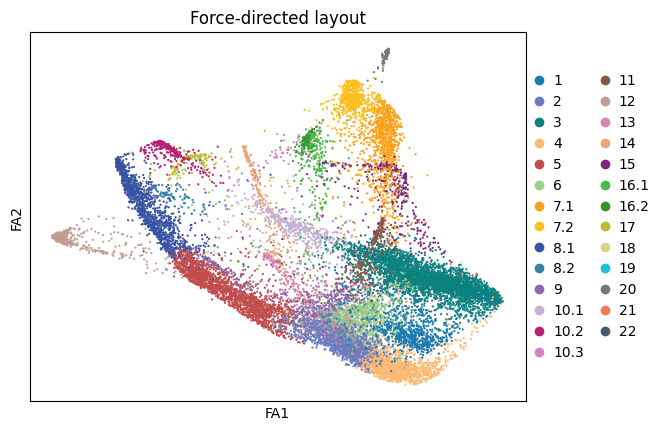

In [7]:
# Plot FDL

scanpy.pl.embedding(basis='draw_graph_fa', adata=adata, color="cluster", size=10, title="Force-directed layout")

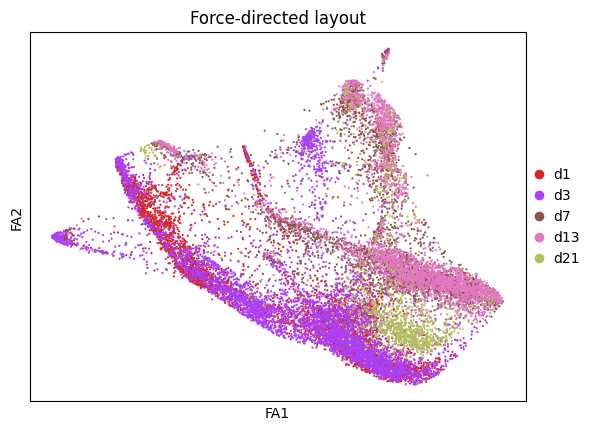

In [8]:
# Plot FDL

scanpy.pl.embedding(basis='draw_graph_fa', adata=adata, color="sample", size=10, title="Force-directed layout")

# Plots of velocity and latent time

computing velocity graph (using 16/64 cores)


  0%|          | 0/16146 [00:00<?, ?cells/s]

    finished (0:00:17) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:02) --> added
    'velocity_draw_graph_fa', embedded velocity vectors (adata.obsm)


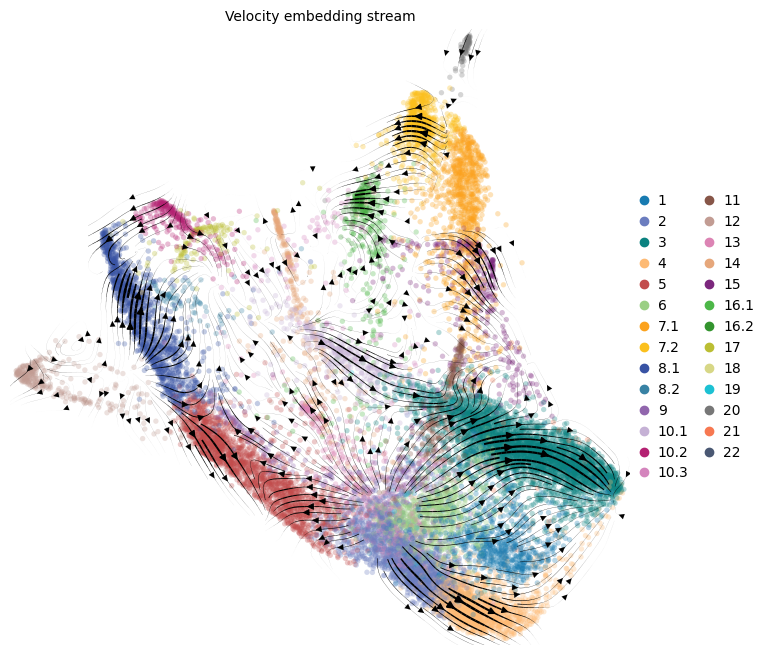

In [9]:
# Plot velocity in FDL

# Velocity cosine correlations
scvelo.tl.velocity_graph(adata, vkey="velocity", n_jobs=16)

scvelo.pl.velocity_embedding_stream(adata, vkey="velocity", basis="draw_graph_fa", color="cluster",
                                    legend_loc="right", figsize=(8,8), title="Velocity embedding stream", density=4)

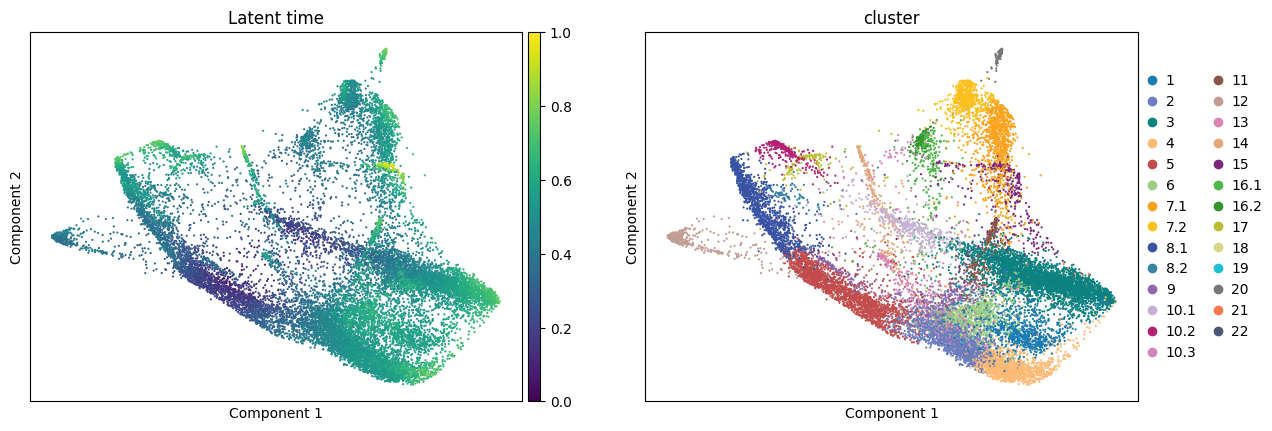

In [10]:
# Latent time on FDL

axis_list = scanpy.pl.embedding(basis="draw_graph_fa", adata=adata, color=["latent_time", "cluster"], size=10, title=["Latent time", "cluster"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()

computing velocity embedding
    finished (0:00:02) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


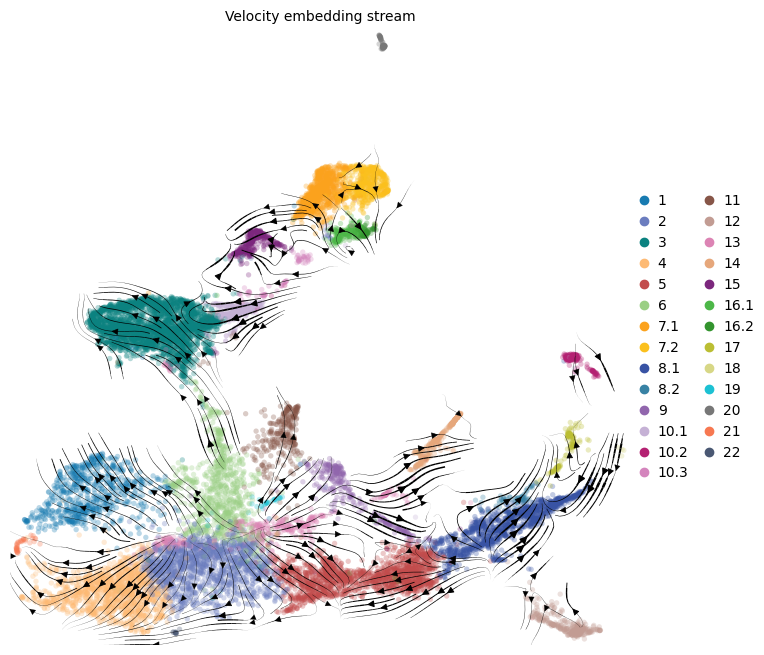

In [11]:
# Velocity on UMAP

scvelo.pl.velocity_embedding_stream(adata, vkey="velocity", basis="umap", color="cluster",
                                    legend_loc="right", figsize=(8,8), title="Velocity embedding stream", density=4)

TypeError: 'Axes' object is not iterable

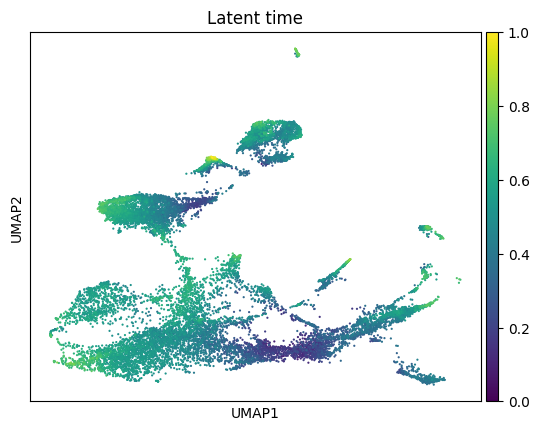

In [12]:
# Latent time on UMAP

axis_list = scanpy.pl.embedding(basis="umap", adata=adata, color="latent_time", size=10, title=["Latent time", "cluster"], show=False)
for axis in axis_list:
    axis.set_xlabel("Component 1")
    axis.set_ylabel("Component 2")
pyplot.show()